In [1]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt

## Defining Parameters

In this section, I want to define the given parameteres.

In [2]:
# Parameters of the SDOF torsional system
I = 0.1  # Inertia in [kg*m^2]
c = 10   # Torsional stiffness in [N*m/rad]

In [3]:
class SDOFTorsionalSystem:

    # Constructor to initialize the system parameters
    def __init__(self, inertia=0, stiffness=0):
        self.I = inertia
        self.c = stiffness
        if self.I > 0 and self.c > 0:
            self.omega_n = self.calculate_natural_frequency()
        else:
            self.omega_n = None

    # Method to calculate the natural frequency of the system
    def calculate_natural_frequency(self):
        return np.sqrt(self.c / self.I)

    # Method to simulate the time response of the system
    # NOTE: modified to account for arbitrary "measurement" excitation
    def simulate_time_response(self, initial_angle=0, initial_velocity=0, time_span=10, load_type="constant", tau_ext=0):
        if self.omega_n is None:
            raise ValueError("Natural frequency is not defined. Please set inertia and stiffness.")
        
        if load_type == "measurement":
            # Time array
            t = tau_ext['time']
            # Torque array
            tau_ti = tau_ext['load']
            # Initialize array for angular displacement to zeros
            theta_t = np.zeros_like(t)
            # Initial conditions
            theta_t[0] = initial_angle
            theta_dot_i = initial_velocity
            # Iteratively calculate the angular displacement at each time step
            for i in range(len(t)-1):
                # Calculate the angular acceleration using the equation of motion
                theta_double_dot = (tau_ti[i] - self.c * theta_t[i]) / self.I
                # Update angular velocity and displacement using finite difference approximation
                dt = t[i+1] - t[i]
                theta_dot_i = theta_dot_i + theta_double_dot * dt
                theta_t[i+1] = theta_t[i] + theta_dot_i * dt
        else:
            # Time array
            t = np.linspace(0, time_span, 1000)
            # Natural frequency
            omega_n = self.omega_n
            if load_type == "constant":
                 tau_0 = tau_ext
                 thetaP_0 = tau_0 / self.c
                 thetaP_t = thetaP_0 * np.ones_like(t)  # Particular solution for constant torque
                 thetaPdot_0 = 0
            elif load_type == "linear":
                r = tau_ext
                alpha = r / self.c
                beta = 0
                thetaP_t = alpha * t + beta  # Particular solution for linear torque ramp
                thetaP_0 = thetaP_t[0]  # Initial value of the particular solution at t=0
                thetaPdot_0 = r / self.c  # Initial value of the derivative of the particular solution at t=0
            elif load_type == "harmonic":
                tau_0 = tau_ext['amplitude']
                omega_f = tau_ext['frequency'] * 2 * np.pi  # Convert frequency from Hz to rad/s
                A_P = tau_0 / (self.c - self.I * omega_f**2)
                B_P = 0
                thetaP_t = A_P * np.sin(omega_f * t) + B_P * np.cos(omega_f * t)  # Particular solution for harmonic excitation
                thetaP_0 = thetaP_t[0]  # Initial value of the particular solution at t=0
                thetaPdot_0 = A_P * omega_f * np.cos(omega_f * t)[0]  # Initial value of the derivative of the particular solution at t=0
            else:
                raise ValueError("Unsupported load type. Please specify 'constant' for constant external torque, 'linear' for linear torque ramp, or 'harmonic' for harmonic excitation.")

            # Calculate the constants A and B based on initial conditions
            A = initial_angle - thetaP_0  # Adjusting for the particular solution at t=0
            B = (initial_velocity - thetaPdot_0) / omega_n  # Adjusting for the derivative of the particular solution at t=0
            # General solution for the homogeneous part
            thetaG_t = A * np.cos(omega_n * t) + B * np.sin(omega_n * t)
            # Time response using the analytical solution for the specified load type
            theta_t = thetaG_t + thetaP_t
        return t, theta_t

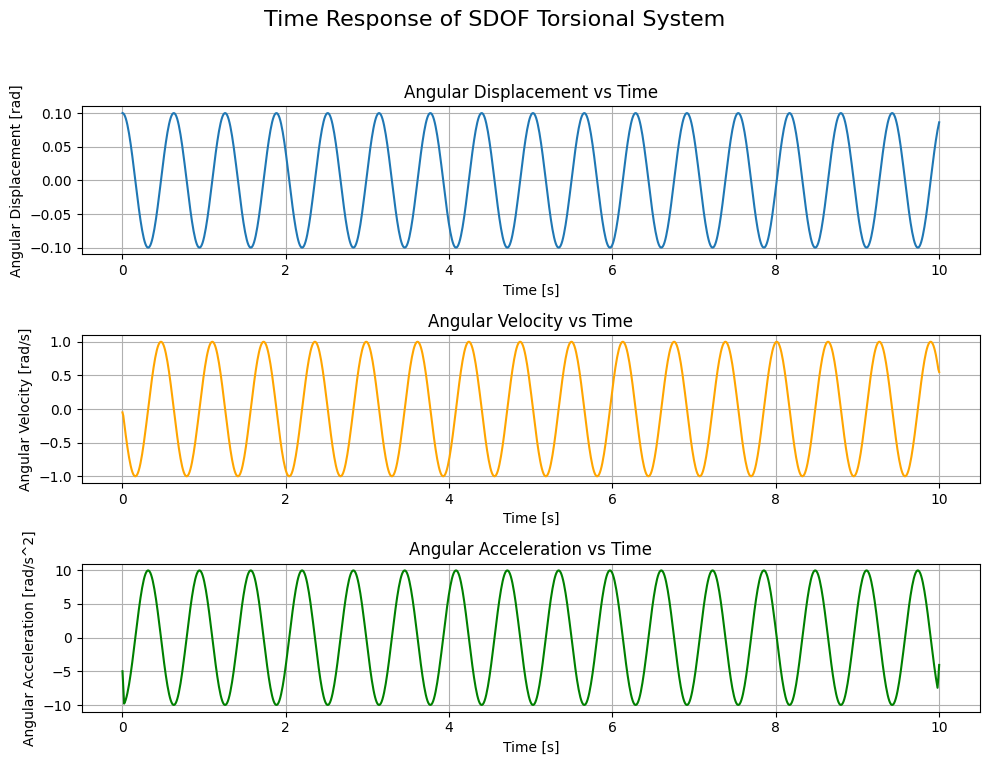

In [4]:
# Create an instance of the SDOF torsional system
S = SDOFTorsionalSystem(inertia=I, stiffness=c)

# Initial conditions
initial_angle = 0.1  # Initial angular displacement in [rad]
initial_velocity = 0.0  # Initial angular velocity in [rad/s]

# Simulate time response
time_span = 10  # Time span for simulation in [s]
t, theta_t = S.simulate_time_response(initial_angle=initial_angle, initial_velocity=initial_velocity, time_span=time_span)

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Angular Displacement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
axes[1].plot(t, angular_velocity, label='Angular Velocity', color='orange')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

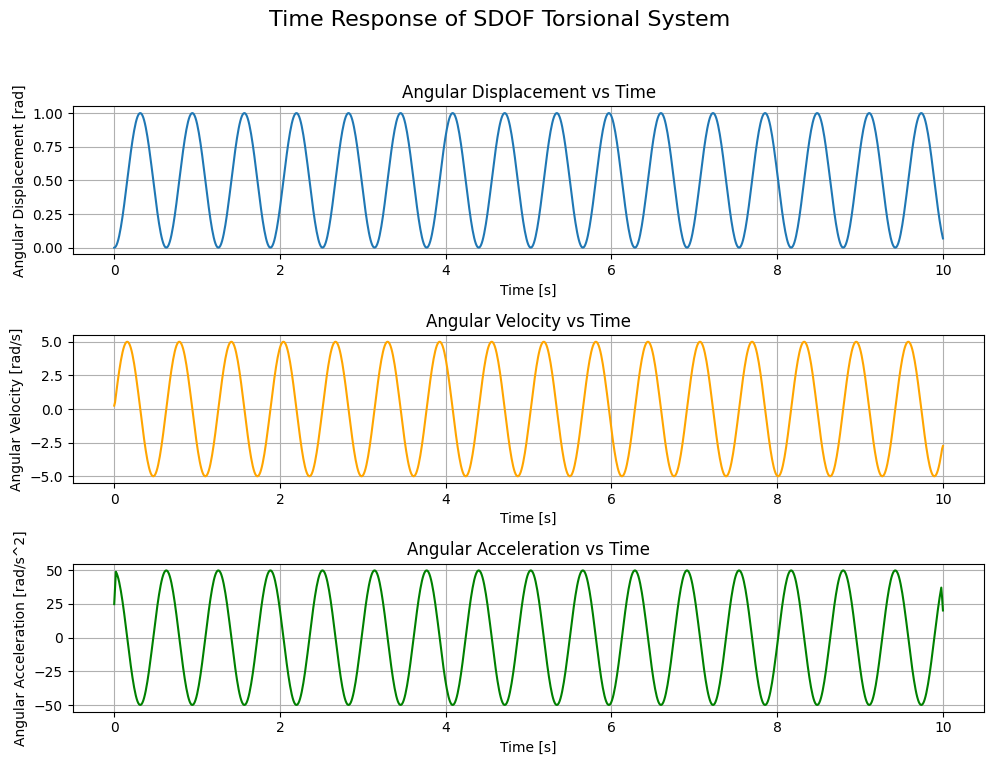

In [5]:
# Simulate time response with a constant external torque
tau_ext = 5  # Constant external torque in [N*m]
t, theta_t = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=time_span, load_type="constant", tau_ext=tau_ext)

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Angular Displacement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
axes[1].plot(t, angular_velocity, label='Angular Velocity', color='orange')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

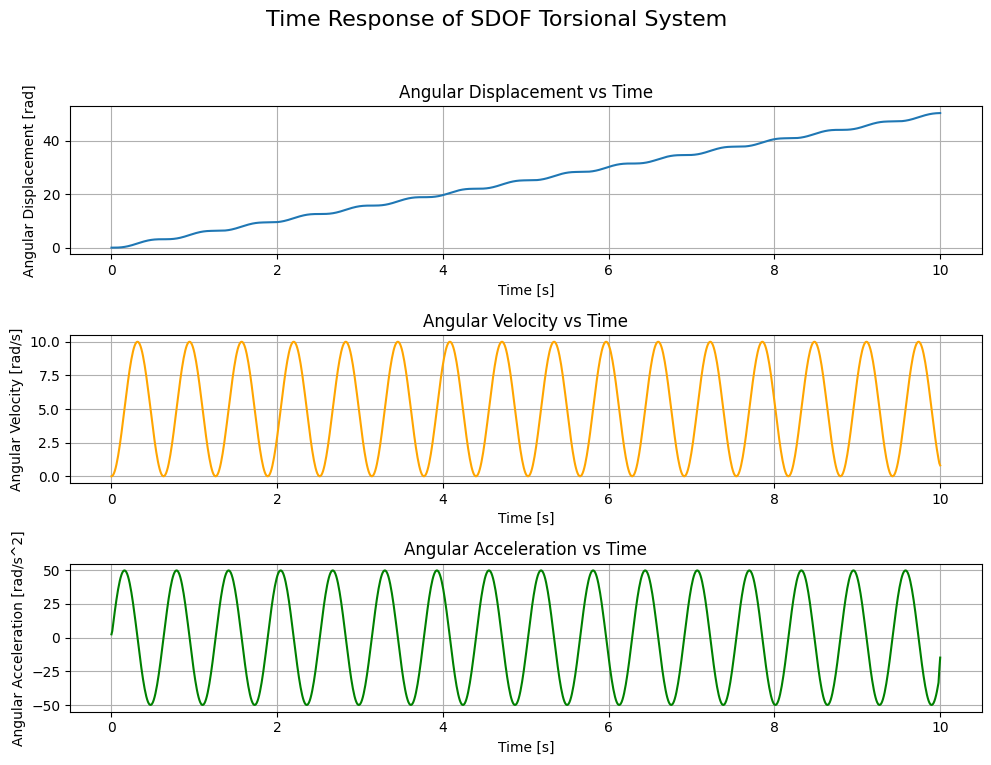

In [6]:
# Simulate time response with a linear torque ramp
tau_ext = 50  # Rate of change of the torque in [N*m/s]
t, theta_t = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=time_span, load_type="linear", tau_ext=tau_ext)

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Angular Displacement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
axes[1].plot(t, angular_velocity, label='Angular Velocity', color='orange')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

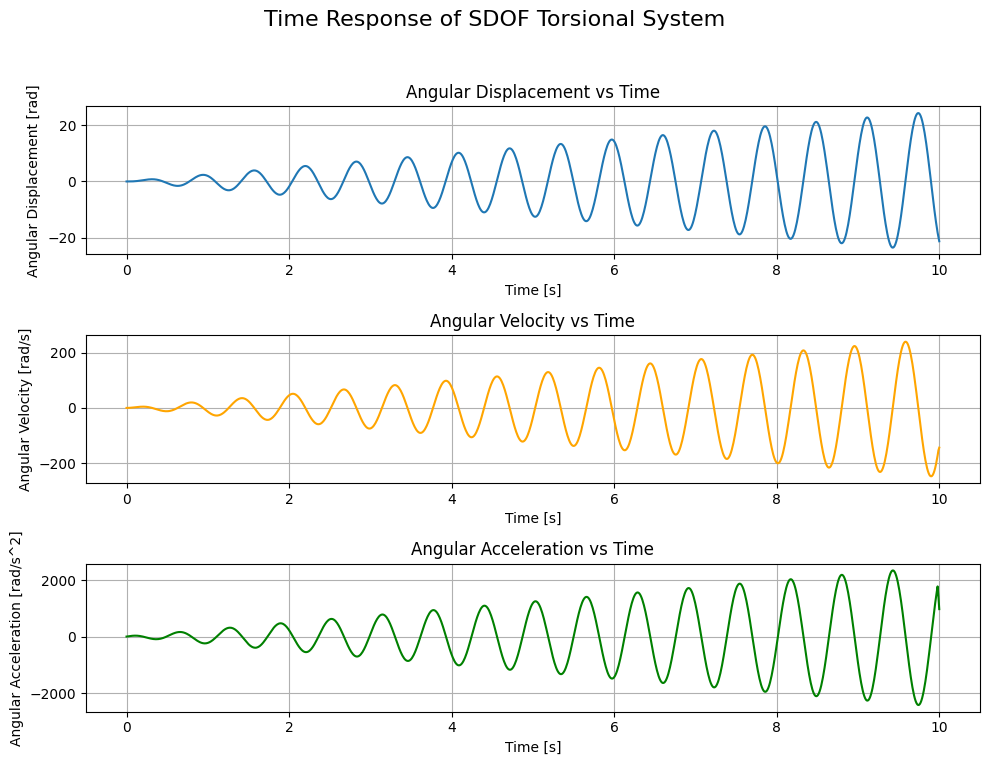

In [7]:
# Simulate time response with a harmonic excitation
tau_0 = 5  # Amplitude of the harmonic excitation in [N*m]
f_excitation = 10/2/np.pi-1e-3  # Frequency of the harmonic excitation in [Hz]
tau_ext = {'amplitude': tau_0, 'frequency': f_excitation}
t, theta_t = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=10, load_type="harmonic", tau_ext=tau_ext)

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Angular Displacement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
axes[1].plot(t, angular_velocity, label='Angular Velocity', color='orange')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

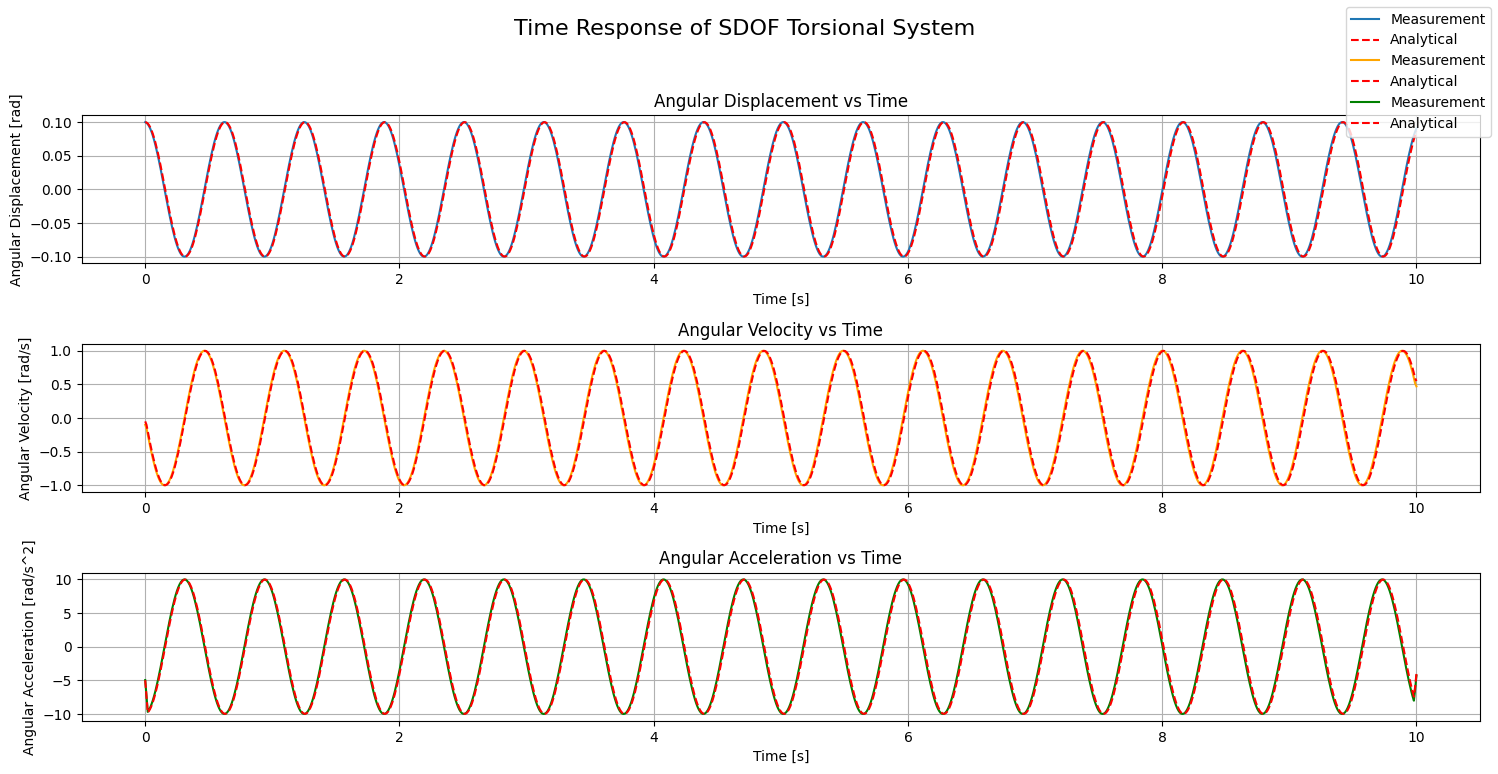

In [8]:
# Simulate time response with a arbitrary excitation: free vibration
time_array = np.linspace(0, 10, 1000) # Time array [s]
load_array = np.zeros_like(time_array)
tau_ext = {'time': time_array, 'load': load_array}
t, theta_t = S.simulate_time_response(initial_angle=0.1, initial_velocity=0, time_span=10, load_type="measurement", tau_ext=tau_ext)

t_an, theta_t_an = S.simulate_time_response(initial_angle=0.1, initial_velocity=0, time_span=10)

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(15, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Measurement')
axes[0].plot(t_an, theta_t_an, linestyle='--', color="red", label='Analytical')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
angular_velocity_an = np.gradient(theta_t_an, t_an)
axes[1].plot(t, angular_velocity, label='Measurement', color='orange')
axes[1].plot(t_an, angular_velocity_an, linestyle='--', color='red', label='Analytical')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
angular_acceleration_an = np.gradient(angular_velocity_an, t_an)
axes[2].plot(t, angular_acceleration, label='Measurement', color='green')
axes[2].plot(t_an, angular_acceleration_an, linestyle='--', color='red', label='Analytical')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

fig.legend()

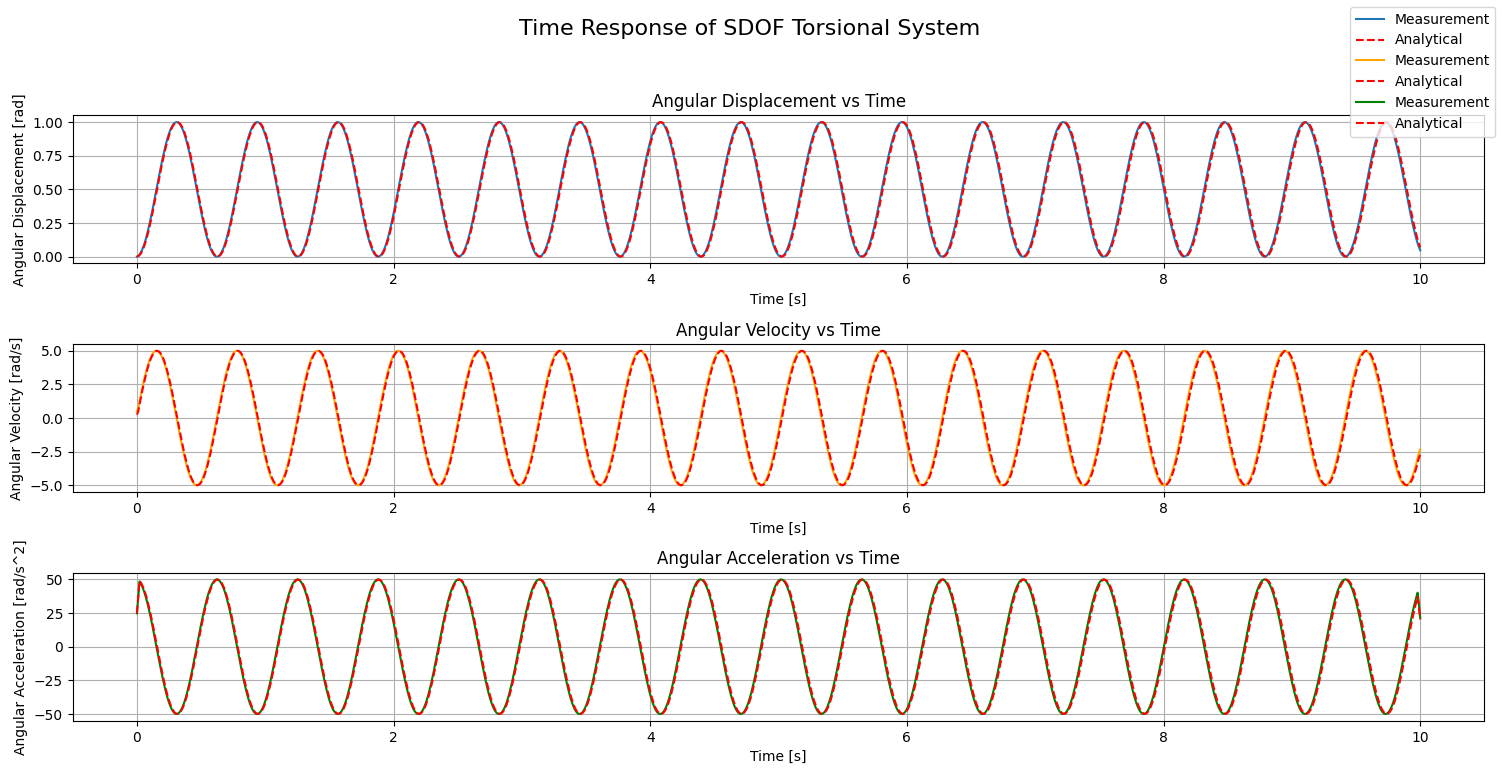

In [9]:
# Simulate time response with a arbitrary excitation: constant
time_array = np.linspace(0, 10, 1000) # Time array [s]
load_array = 5 * np.ones_like(time_array) # Load array [Nm]
tau_ext = {'time': time_array, 'load': load_array}
# Numerical solution
t, theta_t = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=10, load_type="measurement", tau_ext=tau_ext)
# Analytical solution
t_an, theta_t_an = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=10, load_type="constant", tau_ext=5)

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(15, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Measurement')
axes[0].plot(t_an, theta_t_an, linestyle='--', color="red", label='Analytical')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
angular_velocity_an = np.gradient(theta_t_an, t_an)
axes[1].plot(t, angular_velocity, label='Measurement', color='orange')
axes[1].plot(t_an, angular_velocity_an, linestyle='--', color='red', label='Analytical')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
angular_acceleration_an = np.gradient(angular_velocity_an, t_an)
axes[2].plot(t, angular_acceleration, label='Measurement', color='green')
axes[2].plot(t_an, angular_acceleration_an, linestyle='--', color='red', label='Analytical')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

fig.legend()

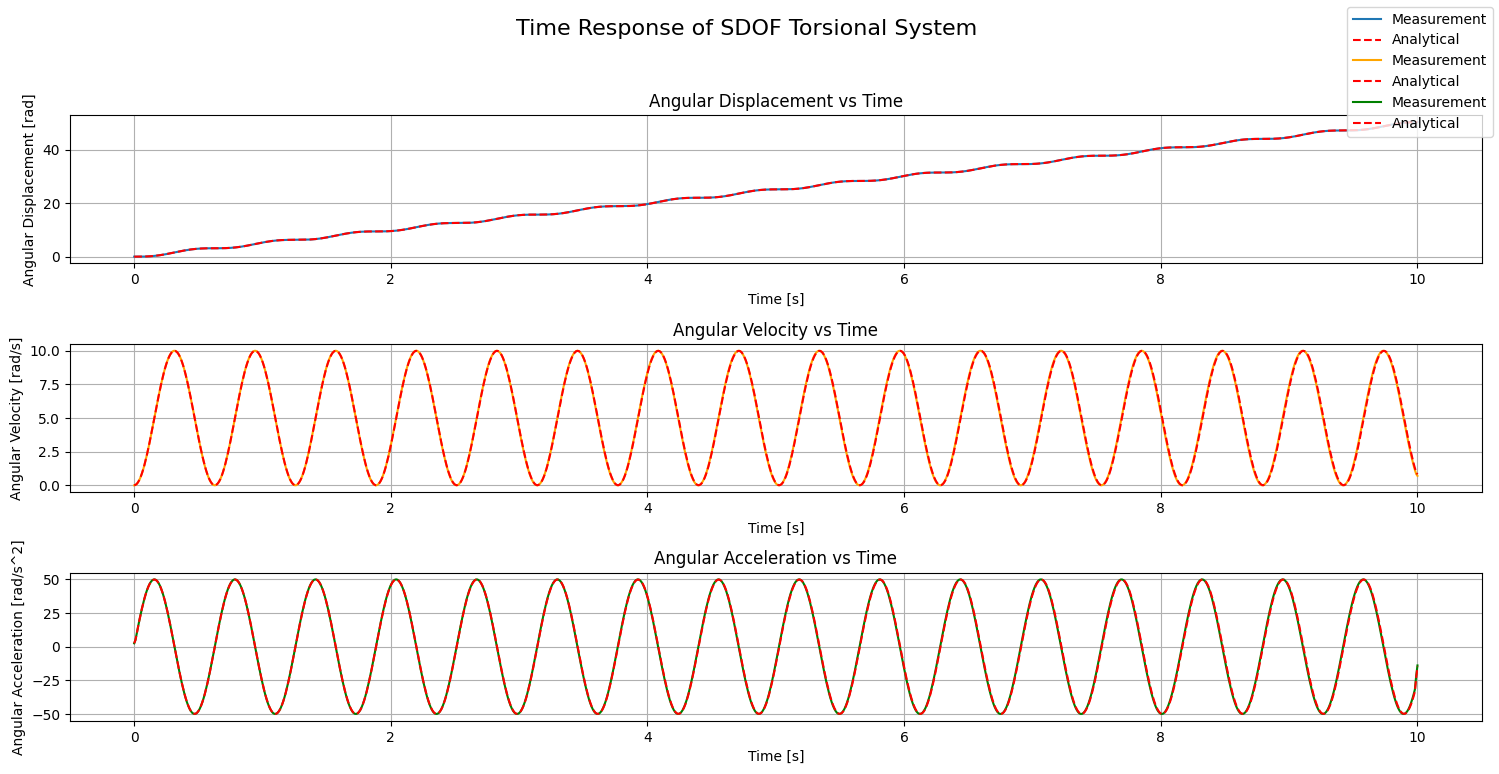

In [10]:
# Simulate time response with a arbitrary excitation: ramp
time_array = np.linspace(0, 10, 1000) # Time array [s]
load_array = 50 * time_array
tau_ext = {'time': time_array, 'load': load_array}
t, theta_t = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=10, load_type="measurement", tau_ext=tau_ext)

t_an, theta_t_an = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=10, load_type="linear", tau_ext=50)

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(15, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Measurement')
axes[0].plot(t_an, theta_t_an, linestyle='--', color="red", label='Analytical')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
angular_velocity_an = np.gradient(theta_t_an, t_an)
axes[1].plot(t, angular_velocity, label='Measurement', color='orange')
axes[1].plot(t_an, angular_velocity_an, linestyle='--', color='red', label='Analytical')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
angular_acceleration_an = np.gradient(angular_velocity_an, t_an)
axes[2].plot(t, angular_acceleration, label='Measurement', color='green')
axes[2].plot(t_an, angular_acceleration_an, linestyle='--', color='red', label='Analytical')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

fig.legend()

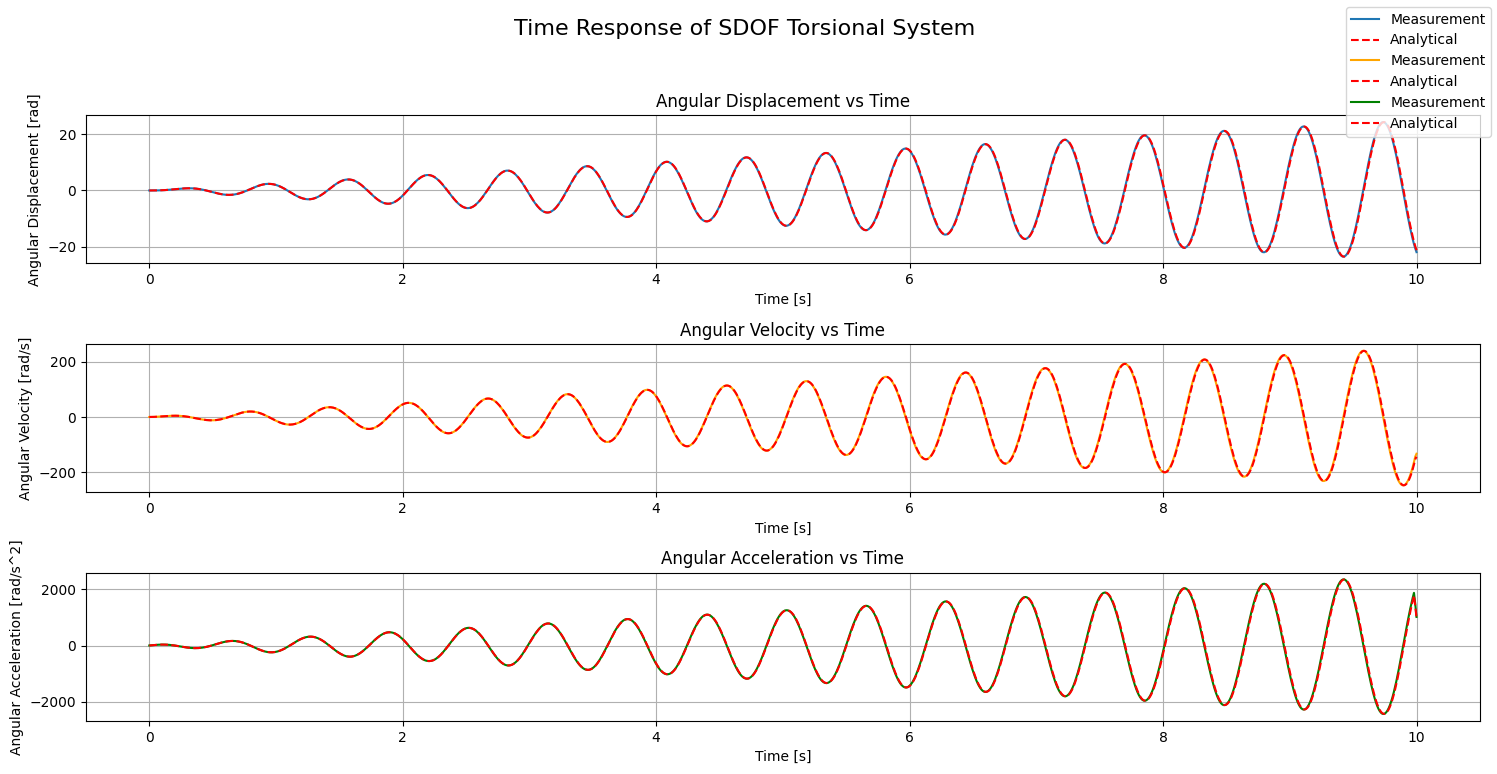

In [11]:
# Simulate time response with a arbitrary excitation: harmonic
time_array = np.linspace(0, 10, 1000) # Time array [s]
omega_f = 10 # Excitation frequency [rad/s]
load_array = 5 * np.sin(omega_f * time_array)
tau_ext = {'time': time_array, 'load': load_array}
t, theta_t = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=10, load_type="measurement", tau_ext=tau_ext)

t_an, theta_t_an = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=10, load_type="harmonic", tau_ext={'amplitude': 5, 'frequency': 10/2/np.pi-1e-3})

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(15, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Measurement')
axes[0].plot(t_an, theta_t_an, linestyle='--', color='red', label='Analytical')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
angular_velocity_an = np.gradient(theta_t_an, t_an)
axes[1].plot(t, angular_velocity, label='Measurement', color='orange')
axes[1].plot(t_an, angular_velocity_an, linestyle='--', color='red', label='Analytical')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
angular_acceleration_an = np.gradient(angular_velocity_an, t_an)
axes[2].plot(t, angular_acceleration, label='Measurement', color='green')
axes[2].plot(t_an, angular_acceleration_an, linestyle='--', color='red', label='Analytical')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

fig.legend()

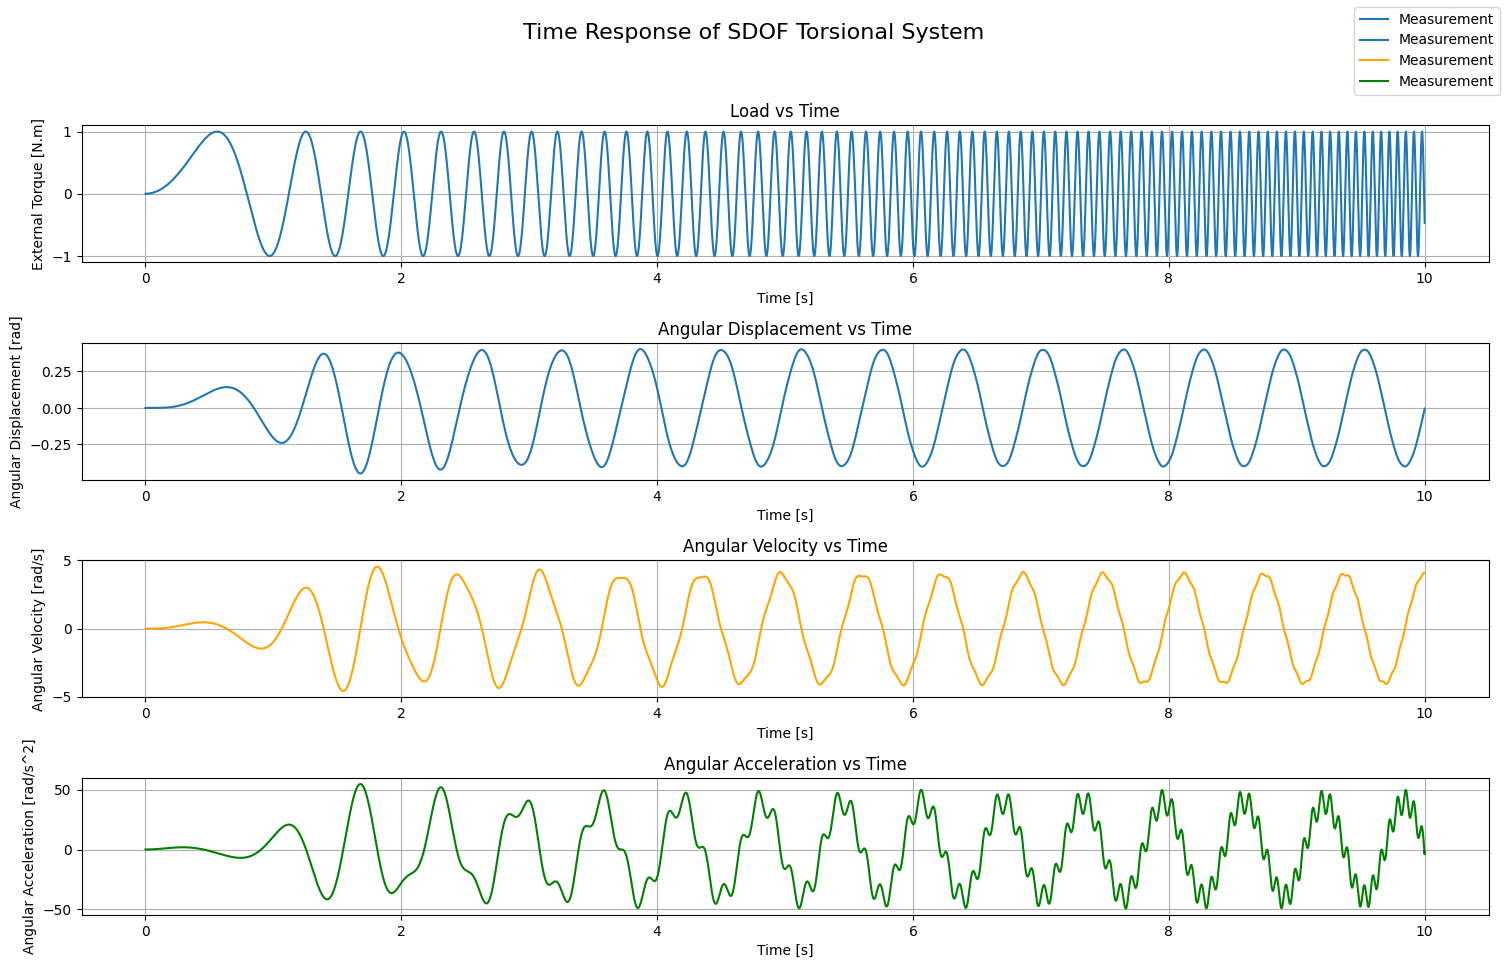

In [12]:
# Simulate time response with a arbitrary excitation: chirp
time_array = np.linspace(0, 10, 100000) # Time array [s]
omega_f = np.linspace(1e-3, 50, 100000) # Excitation frequency [rad/s]
load_array = np.sin(omega_f * time_array)
tau_ext = {'time': time_array, 'load': load_array}
t, theta_t = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=10, load_type="measurement", tau_ext=tau_ext)


# Plotting the time response
fig, axes = plt.subplots(4, 1, figsize=(15, 10))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Load vs Time
# Angular Displacement vs Time
axes[0].plot(t, load_array, label='Measurement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('External Torque [N.m]')
axes[0].set_title('Load vs Time')
axes[0].grid(True)


# Angular Displacement vs Time
axes[1].plot(t, theta_t, label='Measurement')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Displacement [rad]')
axes[1].set_title('Angular Displacement vs Time')
axes[1].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
angular_velocity_an = np.gradient(theta_t_an, t_an)
axes[2].plot(t, angular_velocity, label='Measurement', color='orange')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Velocity [rad/s]')
axes[2].set_title('Angular Velocity vs Time')
axes[2].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
angular_acceleration_an = np.gradient(angular_velocity_an, t_an)
axes[3].plot(t, angular_acceleration, label='Measurement', color='green')
axes[3].set_xlabel('Time [s]')
axes[3].set_ylabel('Angular Acceleration [rad/s^2]')
axes[3].set_title('Angular Acceleration vs Time')
axes[3].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

fig.legend()

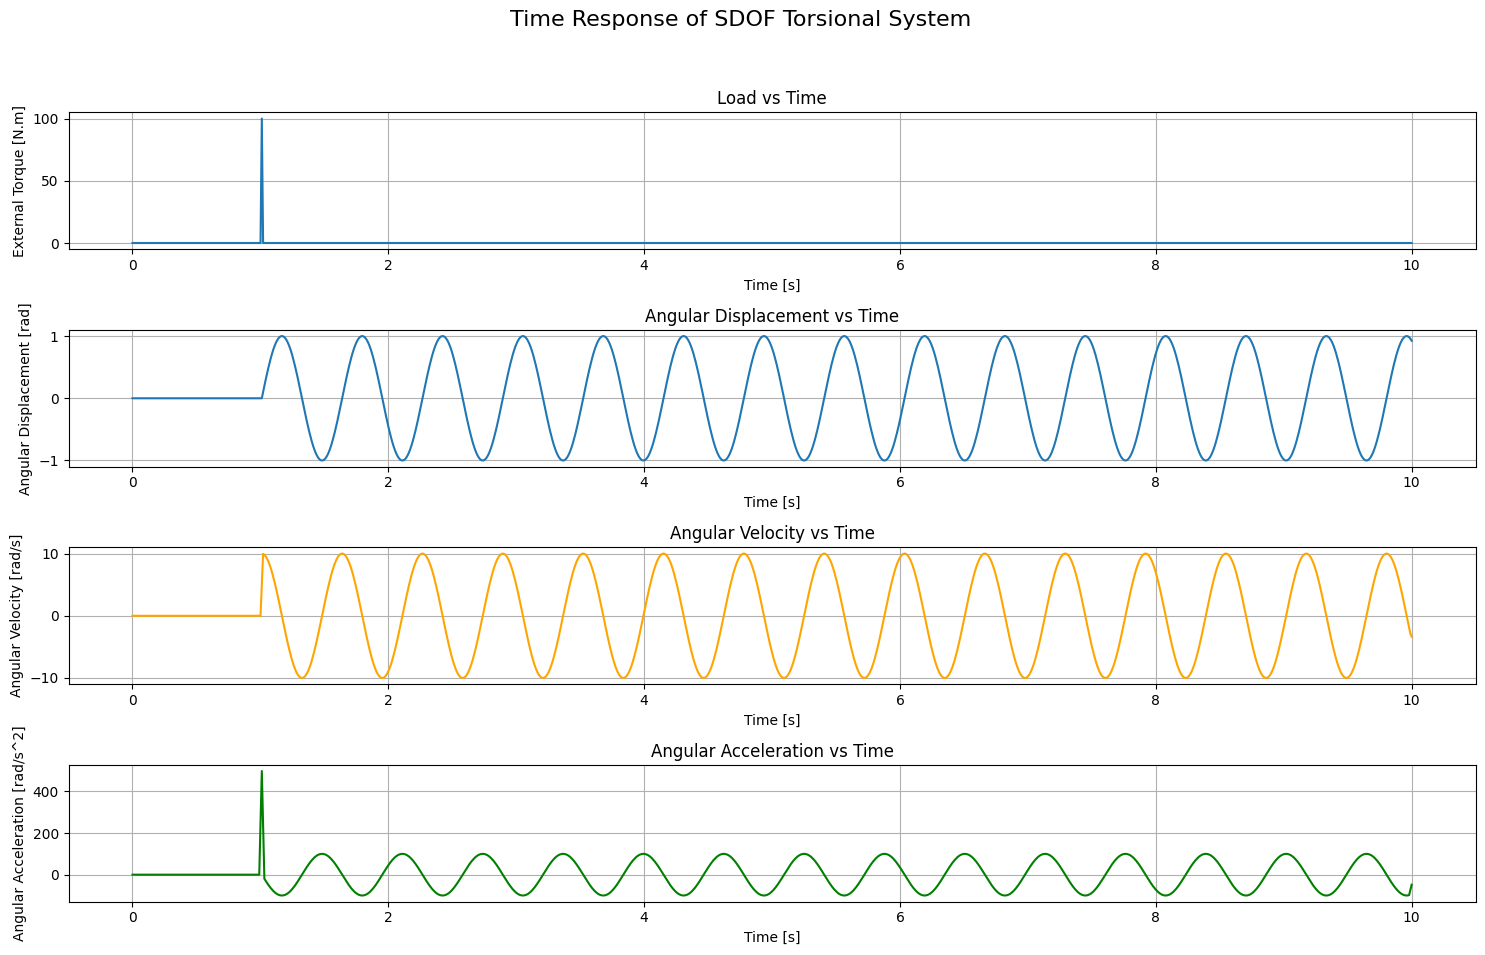

In [13]:
# Simulate time response with a arbitrary excitation: hammer
time_array = np.linspace(0, 10, 1000) # Time array [s]
load_array = np.zeros_like(time_array)
load_array[101] = 1e2
tau_ext = {'time': time_array, 'load': load_array}
t, theta_t = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=10, load_type="measurement", tau_ext=tau_ext)


# Plotting the time response
fig, axes = plt.subplots(4, 1, figsize=(15, 10))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Load vs Time
# Angular Displacement vs Time
axes[0].plot(t, load_array, label='Measurement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('External Torque [N.m]')
axes[0].set_title('Load vs Time')
axes[0].grid(True)


# Angular Displacement vs Time
axes[1].plot(t, theta_t, label='Measurement')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Displacement [rad]')
axes[1].set_title('Angular Displacement vs Time')
axes[1].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
angular_velocity_an = np.gradient(theta_t_an, t_an)
axes[2].plot(t, angular_velocity, label='Measurement', color='orange')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Velocity [rad/s]')
axes[2].set_title('Angular Velocity vs Time')
axes[2].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
angular_acceleration_an = np.gradient(angular_velocity_an, t_an)
axes[3].plot(t, angular_acceleration, label='Measurement', color='green')
axes[3].set_xlabel('Time [s]')
axes[3].set_ylabel('Angular Acceleration [rad/s^2]')
axes[3].set_title('Angular Acceleration vs Time')
axes[3].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

## Refactor: All Polynomials

In [ ]:
class SDOFTorsionalSystem:

    # Constructor to initialize the system parameters
    def __init__(self, inertia=0, stiffness=0):
        self.I = inertia
        self.c = stiffness
        if self.I > 0 and self.c > 0:
            self.omega_n = self.calculate_natural_frequency()
        else:
            self.omega_n = None

    # Method to calculate the natural frequency of the system
    def calculate_natural_frequency(self):
        return np.sqrt(self.c / self.I)

    # Method to simulate the time response of the system
    # NOTE: modified to account for any polynomial function
    def simulate_time_response(self, initial_angle=0, initial_velocity=0, time_span=10, load_type="poly", tau_ext=np.array([0], dtype=np.float16)):
        if self.omega_n is None:
            raise ValueError("Natural frequency is not defined. Please set inertia and stiffness.")
        
        if load_type == "measurement":
            # Time array
            t = tau_ext['time']
            # Torque array
            tau_ti = tau_ext['load']
            # Initialize array for angular displacement to zeros
            theta_t = np.zeros_like(t)
            # Initial conditions
            theta_t[0] = initial_angle
            theta_dot_i = initial_velocity
            # Iteratively calculate the angular displacement at each time step
            for i in range(len(t)-1):
                # Calculate the angular acceleration using the equation of motion
                theta_double_dot = (tau_ti[i] - self.c * theta_t[i]) / self.I
                # Update angular velocity and displacement using finite difference approximation
                dt = t[i+1] - t[i]
                theta_dot_i = theta_dot_i + theta_double_dot * dt
                theta_t[i+1] = theta_t[i] + theta_dot_i * dt
        else:
            # Time array
            t = np.linspace(0, time_span, 1000)
            # Natural frequency
            omega_n = self.omega_n
            if load_type == "poly":
                n = len(tau_ext) - 1 # Polynomial Order
                thetaP_i = np.zeros_like(tau_ext)
                thetaP_t = np.zeros_like(t)
                for i, tau_i in enumerate(tau_ext):
                    if i < 2:
                        thetaP_i[i] = tau_i / self.c # Equation of coefficient for i in [0, 1]
                    else:
                        thetaP_i[i] = (tau_i - self.I*(n-i+2)*(n-i+1)*thetaP_i[i-2]) / self.c # Equation of coefficient for i in [2, n]
                    thetaP_t = thetaP_t + thetaP_i[i] * t ** (n-i) # Equation of particular solution as summation of
                thetaP_0 = thetaP_i[-1] # Constant term yields initital condition of theta
                if n > 0:
                    thetaPdot_0 = thetaP_i[-2] # Linear term yields initial condition of theta_dot
                else:
                    thetaPdot_0 = 0 # For free vibrations or constant external load
            elif load_type == "harmonic":
                tau_0 = tau_ext['amplitude']
                omega_f = tau_ext['frequency'] * 2 * np.pi  # Convert frequency from Hz to rad/s
                A_P = tau_0 / (self.c - self.I * omega_f**2)
                B_P = 0
                thetaP_t = A_P * np.sin(omega_f * t) + B_P * np.cos(omega_f * t)  # Particular solution for harmonic excitation
                thetaP_0 = thetaP_t[0]  # Initial value of the particular solution at t=0
                thetaPdot_0 = A_P * omega_f * np.cos(omega_f * t)[0]  # Initial value of the derivative of the particular solution at t=0
            else:
                raise ValueError("Unsupported load type. Please specify 'constant' for constant external torque, 'linear' for linear torque ramp, or 'harmonic' for harmonic excitation.")

            # Calculate the constants A and B based on initial conditions
            A = initial_angle - thetaP_0  # Adjusting for the particular solution at t=0
            B = (initial_velocity - thetaPdot_0) / omega_n  # Adjusting for the derivative of the particular solution at t=0
            # General solution for the homogeneous part
            thetaG_t = A * np.cos(omega_n * t) + B * np.sin(omega_n * t)
            # Time response using the analytical solution for the specified load type
            theta_t = thetaG_t + thetaP_t
        return t, theta_t

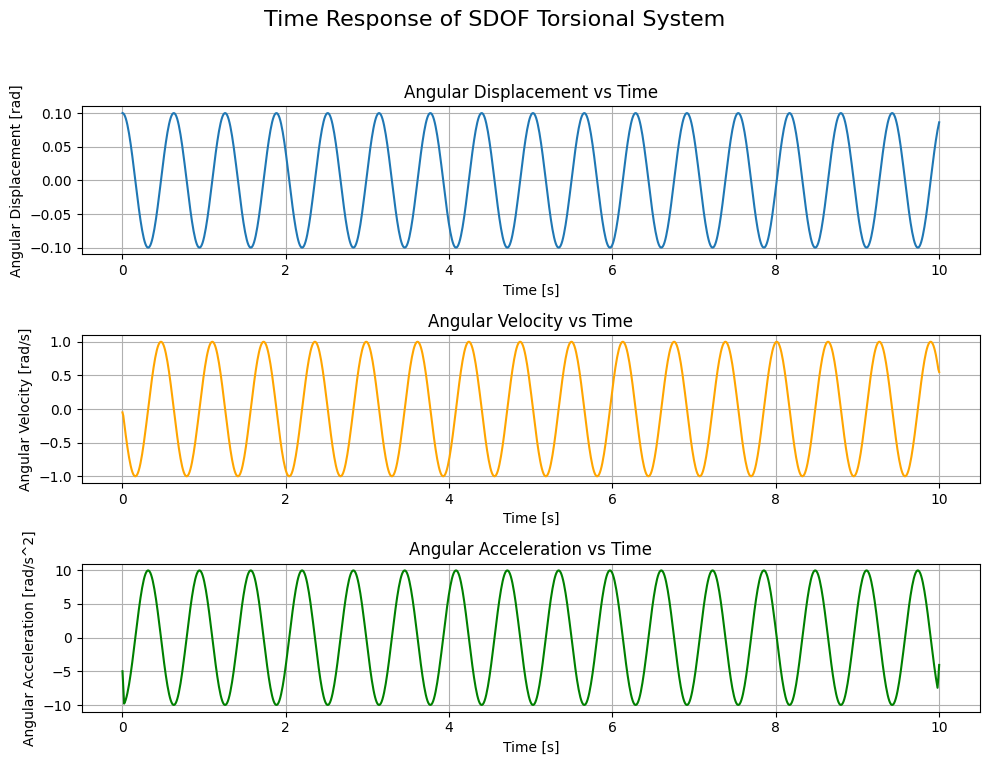

In [11]:
# Create an instance of the SDOF torsional system
S = SDOFTorsionalSystem(inertia=I, stiffness=c)

# Initial conditions
initial_angle = 0.1  # Initial angular displacement in [rad]
initial_velocity = 0.0  # Initial angular velocity in [rad/s]

# Simulate time response for free vibrations
time_span = 10  # Time span for simulation in [s]
t, theta_t = S.simulate_time_response(initial_angle=initial_angle, initial_velocity=initial_velocity, time_span=time_span)

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Angular Displacement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
axes[1].plot(t, angular_velocity, label='Angular Velocity', color='orange')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

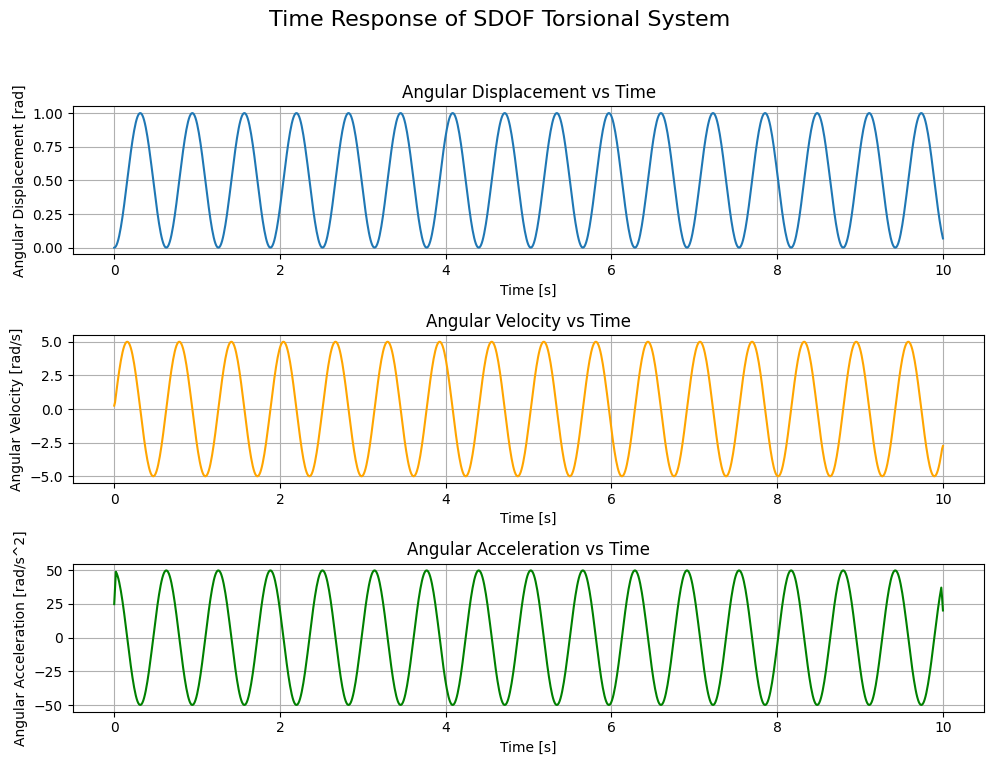

In [ ]:
# Simulate time response for constant external load
time_span = 10  # Time span for simulation in [s]
t, theta_t = S.simulate_time_response(load_type="poly", tau_ext=np.array([5.0]))

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Angular Displacement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
axes[1].plot(t, angular_velocity, label='Angular Velocity', color='orange')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

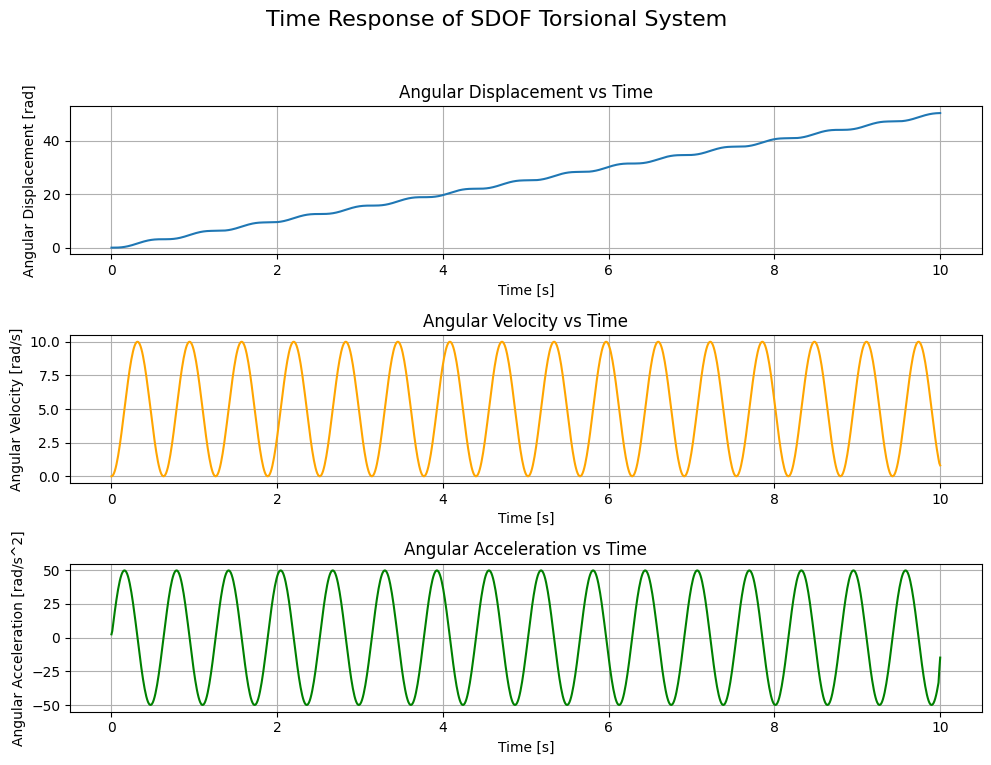

In [18]:
# Simulate time response for linear torque ramp
time_span = 10  # Time span for simulation in [s]
t, theta_t = S.simulate_time_response(load_type="poly", tau_ext=np.array([50, 0], dtype=np.float16))

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Angular Displacement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
axes[1].plot(t, angular_velocity, label='Angular Velocity', color='orange')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

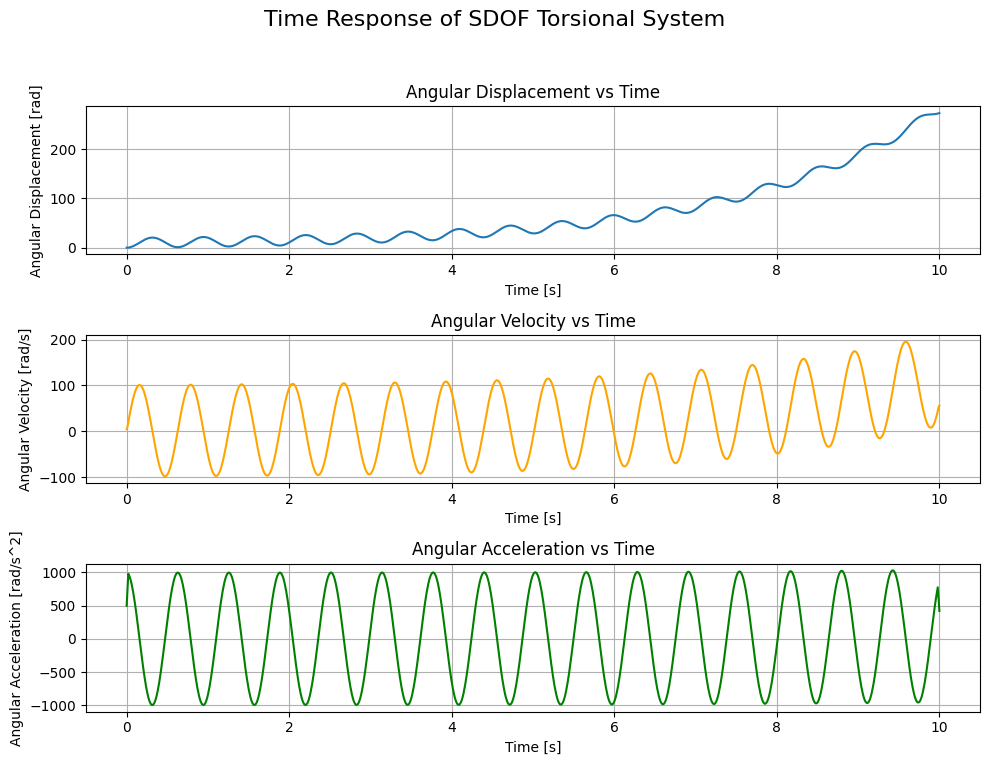

In [31]:
# Simulate time response for 6th order polynomial
time_span = 10  # Time span for simulation in [s]
t, theta_t = S.simulate_time_response(time_span=time_span, load_type="poly", tau_ext=np.array([9e-4, 2e-3, 0.07, 0.3, 5, 12, 100], dtype=np.float16))

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Angular Displacement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
axes[1].plot(t, angular_velocity, label='Angular Velocity', color='orange')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

## Refactor: All Harmonics

In [ ]:
class SDOFTorsionalSystem:

    # Constructor to initialize the system parameters
    def __init__(self, inertia=0, stiffness=0):
        self.I = inertia
        self.c = stiffness
        if self.I > 0 and self.c > 0:
            self.omega_n = self.calculate_natural_frequency()
        else:
            self.omega_n = None

    # Method to calculate the natural frequency of the system
    def calculate_natural_frequency(self):
        return np.sqrt(self.c / self.I)

    # Method to simulate the time response of the system
    # NOTE: modified to account for any harmonic excitation
    def simulate_time_response(self, initial_angle=0, initial_velocity=0, time_span=10, load_type="poly", tau_ext=np.array([0], dtype=np.float16)):
        if self.omega_n is None:
            raise ValueError("Natural frequency is not defined. Please set inertia and stiffness.")
        
        if load_type == "measurement":
            # Time array
            t = tau_ext['time']
            # Torque array
            tau_ti = tau_ext['load']
            # Initialize array for angular displacement to zeros
            theta_t = np.zeros_like(t)
            # Initial conditions
            theta_t[0] = initial_angle
            theta_dot_i = initial_velocity
            # Iteratively calculate the angular displacement at each time step
            for i in range(len(t)-1):
                # Calculate the angular acceleration using the equation of motion
                theta_double_dot = (tau_ti[i] - self.c * theta_t[i]) / self.I
                # Update angular velocity and displacement using finite difference approximation
                dt = t[i+1] - t[i]
                theta_dot_i = theta_dot_i + theta_double_dot * dt
                theta_t[i+1] = theta_t[i] + theta_dot_i * dt
        else:
            # Time array
            t = np.linspace(0, time_span, 1000)
            # Natural frequency
            omega_n = self.omega_n
            if load_type == "poly":
                n = len(tau_ext) - 1 # Polynomial Order
                thetaP_i = np.zeros_like(tau_ext)
                thetaP_t = np.zeros_like(t)
                for i, tau_i in enumerate(tau_ext):
                    if i < 2:
                        thetaP_i[i] = tau_i / self.c # Equation of coefficient for i in [0, 1]
                    else:
                        thetaP_i[i] = (tau_i - self.I*(n-i+2)*(n-i+1)*thetaP_i[i-2]) / self.c # Equation of coefficient for i in [2, n]
                    thetaP_t = thetaP_t + thetaP_i[i] * t ** (n-i) # Equation of particular solution as summation of
                thetaP_0 = thetaP_i[-1] # Constant term yields initital condition of theta
                if n > 0:
                    thetaPdot_0 = thetaP_i[-2] # Linear term yields initial condition of theta_dot
                else:
                    thetaPdot_0 = 0 # For free vibrations or constant external load
            elif load_type == "harmonic":
                # Initialize Particular Solution
                thetaP_t = np.zeros_like(t)
                # Sin terms
                if 'sin' in tau_ext:
                    A_s = tau_ext['sin']['amplitude']
                    omega_s = tau_ext['sin']['frequency'] * 2 * np.pi # Convert frequency from Hz to rad/s
                    if len(A_s) != len(omega_s):
                        raise Exception("Sin terms: amplitudes and frequencies must have the same length.")
                    theta_s_i = np.zeros_like(A_s) # Sin terms of particular solution initialization
                    for i, (A_i, omega_i) in enumerate(zip(A_s, omega_s)):
                        theta_s_i[i] = A_i / (self.c - self.I * omega_i ** 2) # Apply derived formula
                        thetaP_t = thetaP_t + theta_s_i[i] * np.sin(omega_i * t) # Add sin terms
                    thetaPdot_0 = np.sum(theta_s_i)  # Initial value of the derivative of the particular solution at t=0
                else:
                    thetaPdot_0 = 0
                # Cos terms
                if 'cos' in tau_ext:
                    B_c = tau_ext['cos']['amplitude']
                    omega_c = tau_ext['cos']['frequency'] * 2 * np.pi # Convert frequency from Hz to rad/s
                    if len(B_c) != len(omega_c):
                        raise Exception("Cos terms: amplitudes and frequencies must have the same length.")
                    theta_c_j = np.zeros_like(B_c) # Cos terms of particular solution initialization
                    for j, (B_j, omega_j) in enumerate(zip(B_c, omega_c)):
                        theta_c_j[j] = B_j / (self.c - self.I * omega_j ** 2) # Apply derived formula
                        thetaP_t = thetaP_t + theta_c_j[j] * np.cos(omega_j * t) # Add cos terms
                    thetaP_0 = np.sum(theta_c_j)  # Initial value of the particular solution at t=0
                else:
                    thetaP_0 = 0
            else:
                raise ValueError("Unsupported load type. Please specify 'poly' for polynomial excitation, or 'harmonic' for harmonic excitation.")

            # Calculate the constants A and B based on initial conditions
            A = initial_angle - thetaP_0  # Adjusting for the particular solution at t=0
            B = (initial_velocity - thetaPdot_0) / omega_n  # Adjusting for the derivative of the particular solution at t=0
            # General solution for the homogeneous part
            thetaG_t = A * np.cos(omega_n * t) + B * np.sin(omega_n * t)
            # Time response using the analytical solution for the specified load type
            theta_t = thetaG_t + thetaP_t
        return t, theta_t

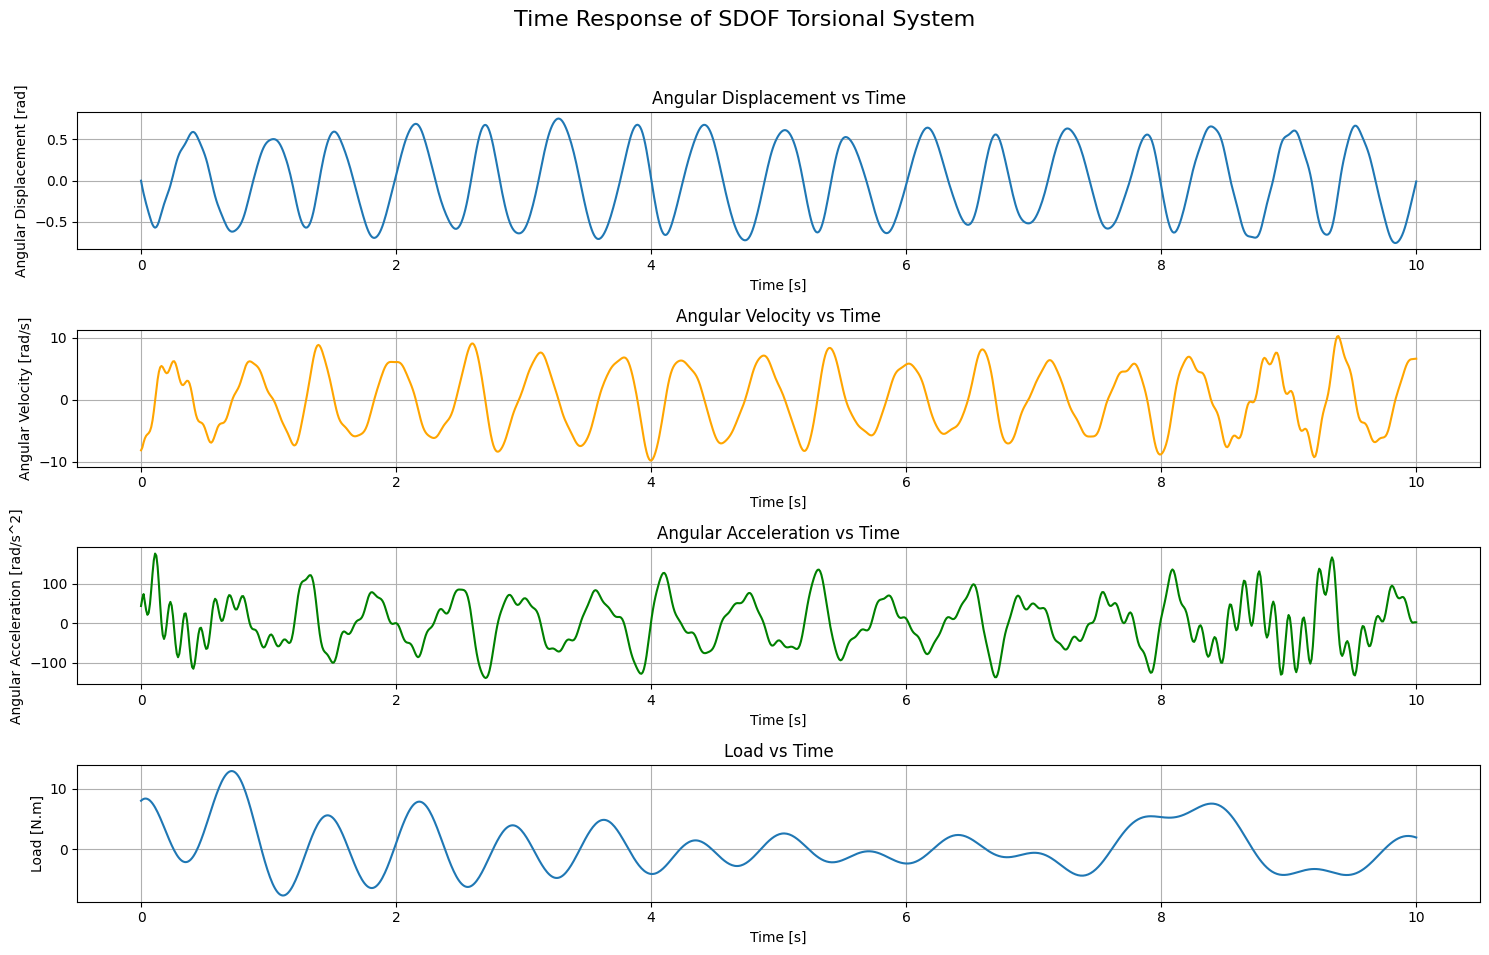

In [47]:
# Simulate time response for mixed harmonics
S = SDOFTorsionalSystem(inertia=I, stiffness=c)
sin_load = {'amplitude': np.linspace(1,2,5), 'frequency': np.linspace(1,4,5)}
cos_load = {'amplitude': np.linspace(0.4, 1.2,10), 'frequency': np.linspace(8,9, 10)}
tau = {'sin': sin_load, 'cos': cos_load}

time_span = 10  # Time span for simulation in [s]
t, theta_t = S.simulate_time_response(time_span=time_span, load_type="harmonic", tau_ext=tau)

# Construct load
load = np.zeros_like(t)
for key in tau:
        for A, om in zip(tau[key]['amplitude'], tau[key]['frequency']):
            if key == 'sin':
                load = load + A * np.sin(om*t)
            elif key == 'cos':
                load = load + A * np.cos(om*t)

# Plotting the time response
fig, axes = plt.subplots(4, 1, figsize=(15, 10))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Angular Displacement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
axes[1].plot(t, angular_velocity, label='Angular Velocity', color='orange')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)

# Plot Load
axes[3].plot(t, load, label='Load')
axes[3].set_xlabel('Time [s]')
axes[3].set_ylabel('Load [N.m]')
axes[3].set_title('Load vs Time')
axes[3].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])